In [1]:
import matplotlib.pyplot as plt
import scienceplots
from matplotlib.ticker import FuncFormatter
import matplotlib as mpl
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
warnings.simplefilter(action='ignore')

# Apply default style and parameters
plt.style.use(['nature', 'science'])


#Default parameters for the main figure, using a commonly available sans-serif font
mpl.rcParams.update({
    'lines.linewidth': 2,
    'lines.markersize': 11,  # Added marker size
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'xtick.major.width': 1,
    'ytick.major.width': 1,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
    'axes.labelsize': 15,
    'axes.titlesize': 15,
    'axes.linewidth': 1.5,  # Increased linewidth for thicker outlines
    'legend.fontsize': 15,
    'legend.handlelength': 2.5,
    'legend.handleheight': 0.75,
    'legend.handletextpad': 0.5,
    'legend.labelspacing': 0.4,
    'axes.prop_cycle': plt.cycler(color=['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#d62728', '#8c564b', '#e377c2', '#7f7f7f', '#17becf', '#bcbd22']),
    'text.usetex': False,  # Disable LaTeX text rendering for compatibility
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],  # Use DejaVu Sans or any available sans-serif font
    'figure.figsize': (7, 5)
})

In [2]:
import pandas as pd
import numpy as np
from scipy.stats import linregress


def get_power_from_voltage(power_df, v):
    vl = power_df["VL (V)"].values
    ps = power_df["Power (W)"].values
    ps -= ps[0]

    sort_ = np.argsort(np.abs(vl - v))
    x = vl[sort_[:2]]
    y = ps[sort_[:2]]

    reg = linregress(x, y)
    return round(1e6*(v * reg.slope + reg.intercept), 2)
    
spot = np.pi*42.9384**2
device = 46.2543*33.6713
factor = device/spot

In [3]:
#raw data
props = catalog.load("properties_project_joaco")
data = catalog.load("data_project_joaco")

#hyst data
props_hysteresis = catalog.load("props_with_maximums_hysteresis_project_joaco")
data_hyst = catalog.load("hysteresis_project_joaco")

hyst850 = props_hysteresis[props_hysteresis["Laser wavelength"]==850]

[04/09/25 20:46:30] INFO     Loading data from properties_project_joaco (CSVDataset)...         ]8;id=640756;file:///Users/mphstph/Documents/GitHub/SnS-Joaquin/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=346155;file:///Users/mphstph/Documents/GitHub/SnS-Joaquin/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#390\390]8;;\

                    INFO     Loading data from data_project_joaco (PartitionedDataset)...       ]8;id=138617;file:///Users/mphstph/Documents/GitHub/SnS-Joaquin/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=793798;file:///Users/mphstph/Documents/GitHub/SnS-Joaquin/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#390\390]8;;\

                    INFO     Loading data from props_with_maximums_hysteresis_project_joaco     ]8;id=237192;file:///Users/mphstph/Documents/GitHub/SnS-Joaquin/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=54396;file:///Users/mphstph/Documents/GitHub/SnS-Joaquin/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#390\390]8;;\
                             (CSVDataset)...                                                                       

                    INFO     Loading data from hysteresis_project_joaco (PartitionedDataset)... ]8;id=342949;file:///Users/mphstph/Documents/GitHub/SnS-Joaquin/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=373883;file:///Users/mphstph/Documents/GitHub/SnS-Joaquin/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#390\390]8;;\

In [4]:
wavelengths = [365, 455, 625, 850]
calibration_data = {}

for wl in wavelengths:
    # 1) Filter the props dataframe
    filtered = props.loc[
        (props["Procedure type"] == "LaserCalibration")
        & (props["Laser wavelength"] == wl)
        & (props["data_key"].str.startswith("2025-04-08"))
    ]
    
    # 2) Extract the data_key
    #    (assuming at least one match; otherwise check if filtered.empty first)
    key = filtered["data_key"].iloc[0]
    
    # 3) Use that key to grab the data
    calibration_data[wl] = data[key]()  # or data[key] if it’s not callable


from scipy.interpolate import interp1d

calibration_fns = {}

# Build one interpolation function per wavelength
for wl, df_cal in calibration_data.items():
    # df_cal has "VL (V)" and "Power (W)"
    f = interp1d(
        df_cal["VL (V)"], 
        df_cal["Power (W)"], 
        kind="linear",        # or "cubic", etc.
        fill_value="extrapolate"  # or "extrapolate"
    )
    calibration_fns[wl] = f


In [5]:

hyst_850_v1 = (
    props
    .query("`VSD end` == 1 and `Laser wavelength` == 850")  # Filtering with query
    .loc[lambda df: df["data_key"].str.startswith("2025-04-01")]  # Applying string filter
    .sort_values("Laser voltage")  # Sorting
)



hyst_850_v2 = (
    props
    .query("`VSD end` == 2 and `Laser wavelength` == 850")  # Filtering with query
    .loc[lambda df: df["data_key"].str.startswith("2025-04-01")]  # Applying string filter
    .sort_values("Laser voltage")  # Sorting
)

#week 3


hyst_850_v8 = (
    props
    .query("`VSD end` == 8 and `Laser wavelength` == 850")  # Filtering with query
    .loc[lambda df: df["data_key"].str.startswith("2025-04-08")]  # Applying string filter
    .sort_values("Laser voltage")  # Sorting
)

#week 3


hyst_625_v8 = (
    props
    .query("`VSD end` == 8 and `Laser wavelength` == 625")  # Filtering with query
    .loc[lambda df: df["data_key"].str.startswith("2025-04-08")]  # Applying string filter
    .sort_values("Laser voltage")  # Sorting
)



hyst_455_v8 = (
    props
    .query("`VSD end` == 8 and `Laser wavelength` == 455")  # Filtering with query
    .loc[lambda df: df["data_key"].str.startswith("2025-04-08")]  # Applying string filter
    .sort_values("Laser voltage")  # Sorting
)

hyst_365_v8 = (
    props
    .query("`VSD end` == 8")  # Filtering with query
    .loc[lambda df: df["data_key"].str.startswith("365")]  # Applying string filter
    .sort_values("Laser voltage")  # Sorting
)

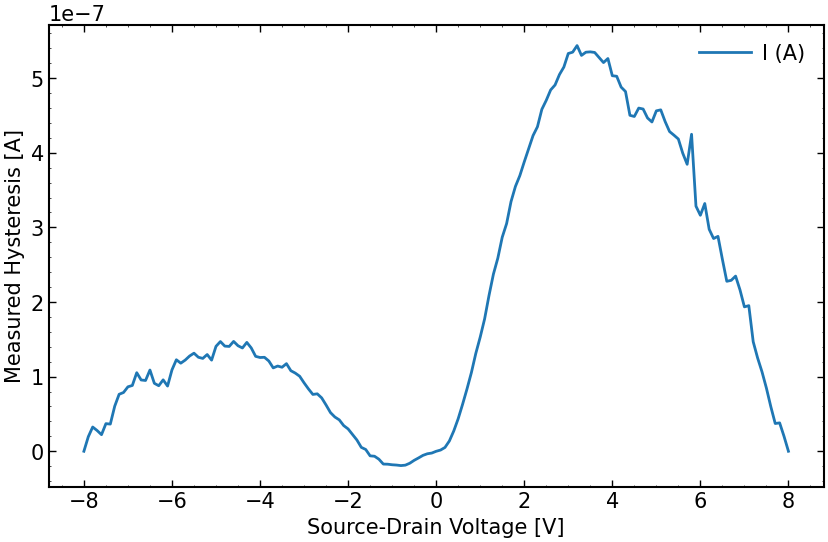

In [6]:
data_to_plot = (
    props
    .query("`VSD end` == 8")  # Filtering with query
    .loc[lambda df: df["data_key"].str.startswith("2025-04-08")]  # Applying string filter
)


# Create the figure and axes with custom size
fig, ax = plt.subplots(figsize=(10, 6))

# Plot your data
data_hyst[data_to_plot.iloc[1]["data_key"]]().plot(x="Vsd (V)", ax=ax)

# Add labels
ax.set_xlabel("Source-Drain Voltage [V]")
ax.set_ylabel("Measured Hysteresis [A]")

# Save the figure
fig.savefig("hysteresis_plot.png", dpi=300)  # Save as high-quality PNG

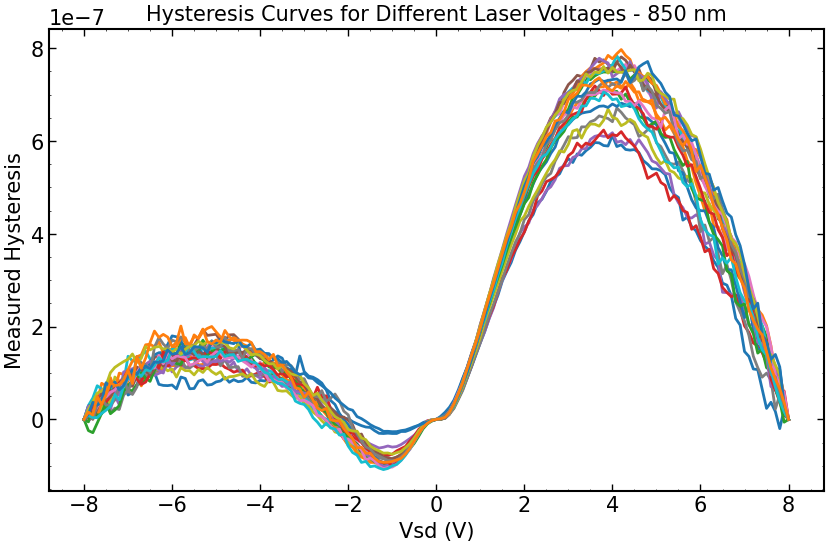

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))  # Create figure and axis

for _, row in hyst_850_v8.iterrows():  
    data_key = row["data_key"]  # Get the key for the dataset
    laser_voltage = row["Laser voltage"]  # Get the laser voltage for labeling
    df = data_hyst[data_key]()  # Load the corresponding dataset
    
    ax.plot(df["Vsd (V)"], df.iloc[:, 1])  # Use second column as y-data

ax.set_xlabel("Vsd (V)")
ax.set_ylabel("Measured Hysteresis")
ax.set_title("Hysteresis Curves for Different Laser Voltages - 850 nm")
#ax.legend(title="Laser Voltage (V)")
#ax.grid(True)
plt.savefig("some_hysteric_850.png")
plt.show()

In [10]:
c = catalog.load("props_with_maximums_hysteresis_project_joaco")
hyst_850_v8_1 = (
    c
    .query("`VSD end` == 8 and `Laser wavelength` == 0")  # Filtering with query
    .loc[lambda df: df["data_key"].str.startswith("850_2")]  # Applying string filter
    .sort_values("Laser voltage")  # Sorting
)

hyst_850_v8_2 = (
    c
    .query("`VSD end` == 8 and `Laser wavelength` == 0")  # Filtering with query
    .loc[lambda df: df["data_key"].str.startswith("850_1")]  # Applying string filter
    .sort_values("Laser voltage")  # Sorting
)


                    INFO     Loading data from props_with_maximums_hysteresis_project_joaco     ]8;id=60647;file:///Users/mphstph/Documents/GitHub/SnS-Joaquin/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=458555;file:///Users/mphstph/Documents/GitHub/SnS-Joaquin/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#390\390]8;;\
                             (CSVDataset)...                                                                       

In [11]:
#hyst_850_v8["pos_neg_hyst_ratio"] = hyst_850_v8["max_positive_hysteresis"] / hyst_850_v8["max_negative_hysteresis"]

<Axes: xlabel='Laser voltage'>

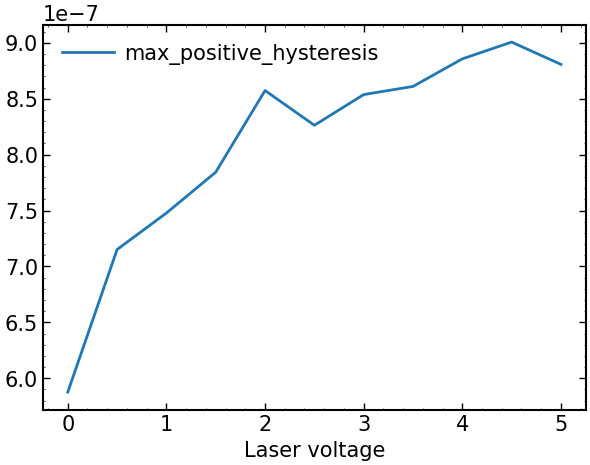

In [12]:
hyst_850_v8_1.plot(x="Laser voltage", y="max_positive_hysteresis")

<Axes: xlabel='Laser voltage'>

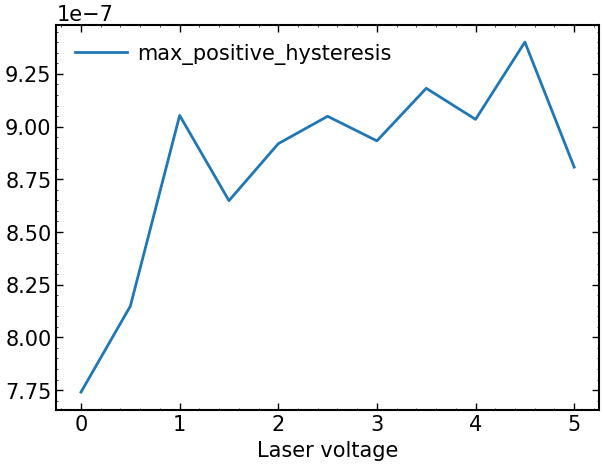

In [13]:
hyst_850_v8_2.plot(x="Laser voltage", y="max_positive_hysteresis")

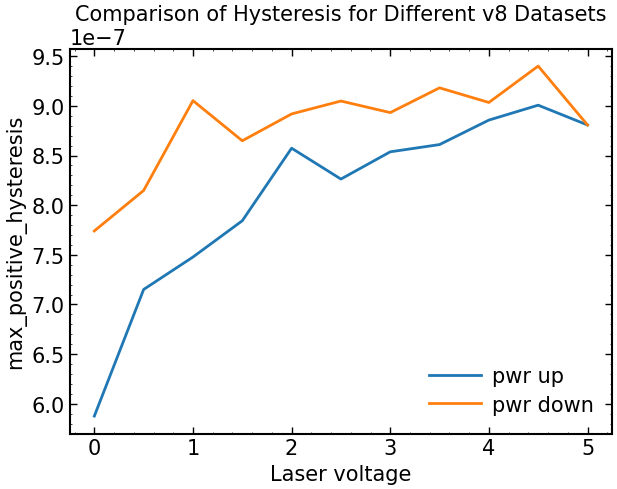

In [14]:
# 1) Plot the first DataFrame, capturing the Axes object
ax = hyst_850_v8_1.plot(
    x="Laser voltage",
    y="max_positive_hysteresis",
    label="pwr up"  # label for the legend
)

# 2) Plot the second DataFrame on the *same* Axes
hyst_850_v8_2.plot(
    x="Laser voltage",
    y="max_positive_hysteresis",
    ax=ax,        # this reuses the Axes
    label="pwr down"
)

# Optional: customize
plt.title("Comparison of Hysteresis for Different v8 Datasets")
plt.xlabel("Laser voltage")
plt.ylabel("max_positive_hysteresis")
plt.legend()  # add legend
plt.show()

In [15]:
hyst_625_v8_1 = (
    c
    .query("`VSD end` == 8 and `Laser wavelength` == 625 and `Information` == 'SnS - 625 - pwr up'")  # Filtering with query
    .loc[lambda df: df["data_key"].str.startswith("2025-04-08")]  # Applying string filter
    .sort_values("Laser voltage")  # Sorting
)

hyst_625_v8_2 = (
    c
    .query("`VSD end` == 8 and `Laser wavelength` == 625 and `Information` == 'SnS - 625 - pwr down'")  # Filtering with query
    .loc[lambda df: df["data_key"].str.startswith("2025-04-08")]  # Applying string filter
    .sort_values("Laser voltage")  # Sorting
)

<Axes: xlabel='Laser voltage'>

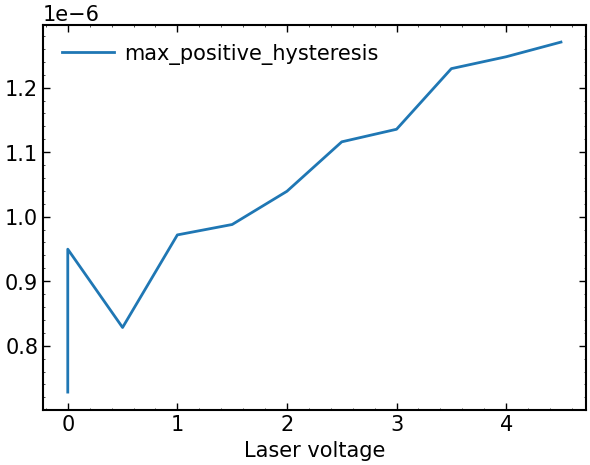

In [16]:
hyst_625_v8_1.plot(x="Laser voltage", y="max_positive_hysteresis")

<Axes: xlabel='Laser voltage'>

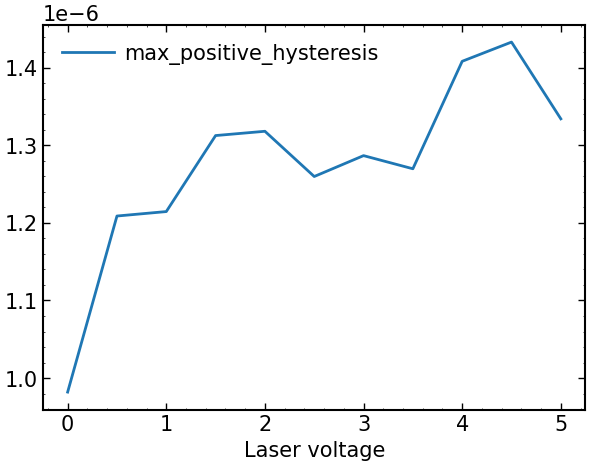

In [17]:
hyst_625_v8_2.plot(x="Laser voltage", y="max_positive_hysteresis")

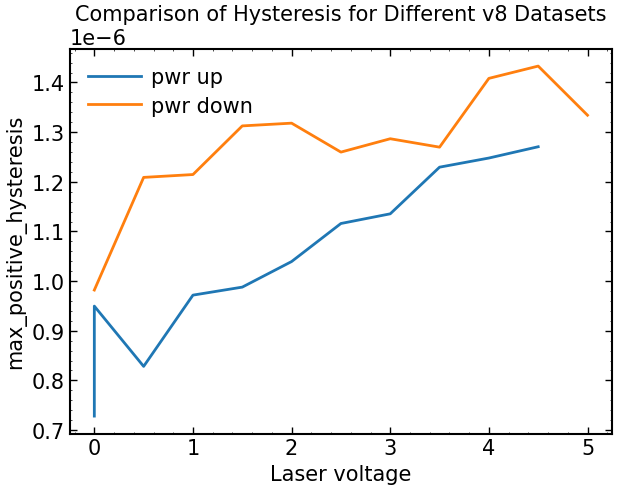

In [18]:
# 1) Plot the first DataFrame, capturing the Axes object
ax = hyst_625_v8_1.plot(
    x="Laser voltage",
    y="max_positive_hysteresis",
    label="pwr up"  # label for the legend
)

# 2) Plot the second DataFrame on the *same* Axes
hyst_625_v8_2.plot(
    x="Laser voltage",
    y="max_positive_hysteresis",
    ax=ax,        # this reuses the Axes
    label="pwr down"
)

# Optional: customize
plt.title("Comparison of Hysteresis for Different v8 Datasets")
plt.xlabel("Laser voltage")
plt.ylabel("max_positive_hysteresis")
plt.legend()  # add legend
plt.show()

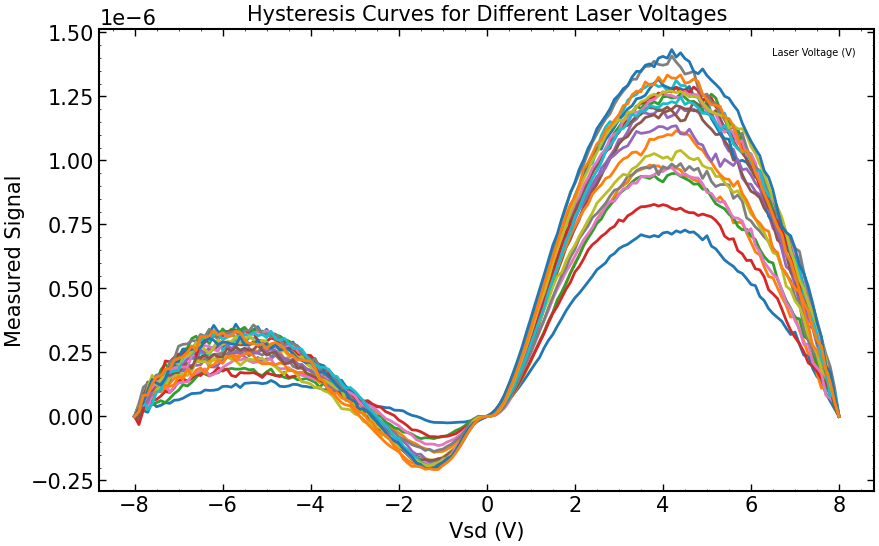

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))  # Create figure and axis

for _, row in hyst_625_v8.iterrows():  
    data_key = row["data_key"]  # Get the key for the dataset
    laser_voltage = row["Laser voltage"]  # Get the laser voltage for labeling
    df = data_hyst[data_key]()  # Load the corresponding dataset
    
    ax.plot(df["Vsd (V)"], df.iloc[:, 1])  # Use second column as y-data

ax.set_xlabel("Vsd (V)")
ax.set_ylabel("Measured Signal")
ax.set_title("Hysteresis Curves for Different Laser Voltages")
ax.legend(title="Laser Voltage (V)")
#ax.grid(True)

plt.show()

In [20]:
hyst_455_v8_1 = (
    c
    .query("`VSD end` == 8 and `Laser wavelength` == 455 and `Information` == 'SnS - 455 - pwr up'")  # Filtering with query
    .loc[lambda df: df["data_key"].str.startswith("2025-04-08")]  # Applying string filter
    .sort_values("Laser voltage")  # Sorting
)

hyst_455_v8_2 = (
    c
    .query("`VSD end` == 8 and `Laser wavelength` == 455 and `Information` == 'SnS - 455 - pwr down'")  # Filtering with query
    .loc[lambda df: df["data_key"].str.startswith("2025-04-08")]  # Applying string filter
    .sort_values("Laser voltage")  # Sorting
)

<Axes: xlabel='Laser voltage'>

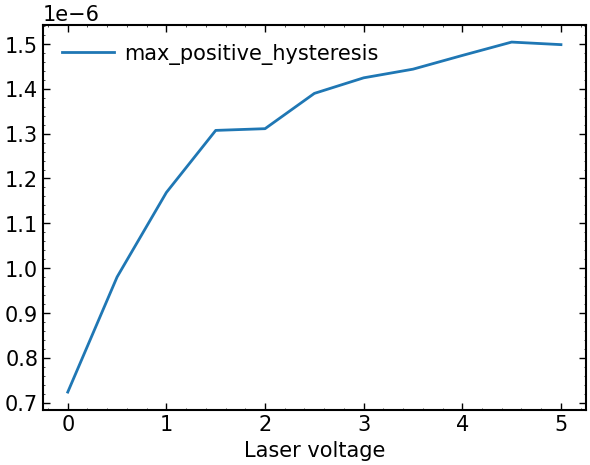

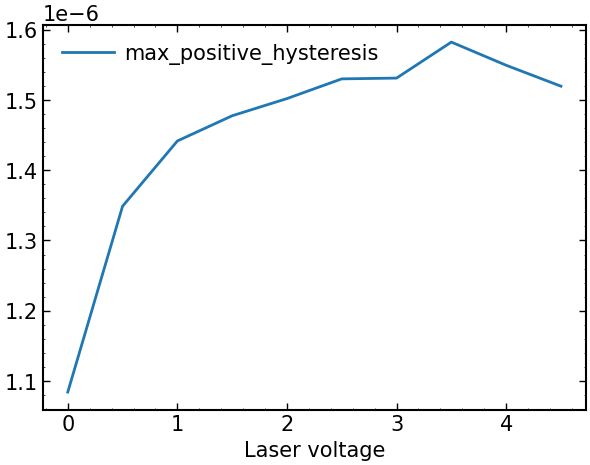

In [21]:
hyst_455_v8_1.plot(x="Laser voltage", y="max_positive_hysteresis")
hyst_455_v8_2.plot(x="Laser voltage", y="max_positive_hysteresis")

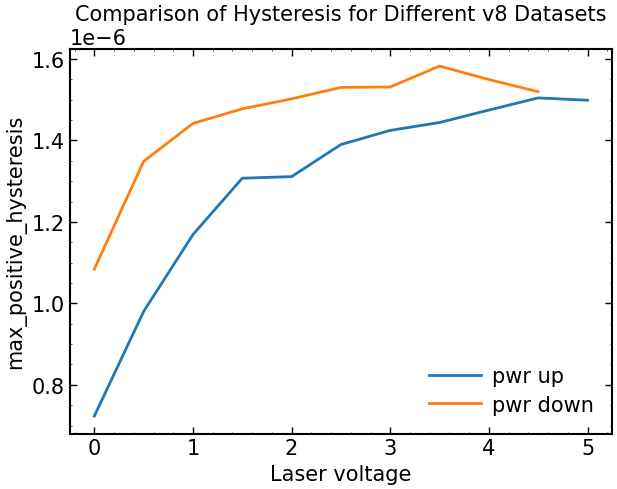

In [22]:

# 1) Plot the first DataFrame, capturing the Axes object
ax = hyst_455_v8_1.plot(
    x="Laser voltage",
    y="max_positive_hysteresis",
    label="pwr up"  # label for the legend
)

# 2) Plot the second DataFrame on the *same* Axes
hyst_455_v8_2.plot(
    x="Laser voltage",
    y="max_positive_hysteresis",
    ax=ax,        # this reuses the Axes
    label="pwr down"
)

# Optional: customize
plt.title("Comparison of Hysteresis for Different v8 Datasets")
plt.xlabel("Laser voltage")
plt.ylabel("max_positive_hysteresis")
plt.legend()  # add legend
plt.show()


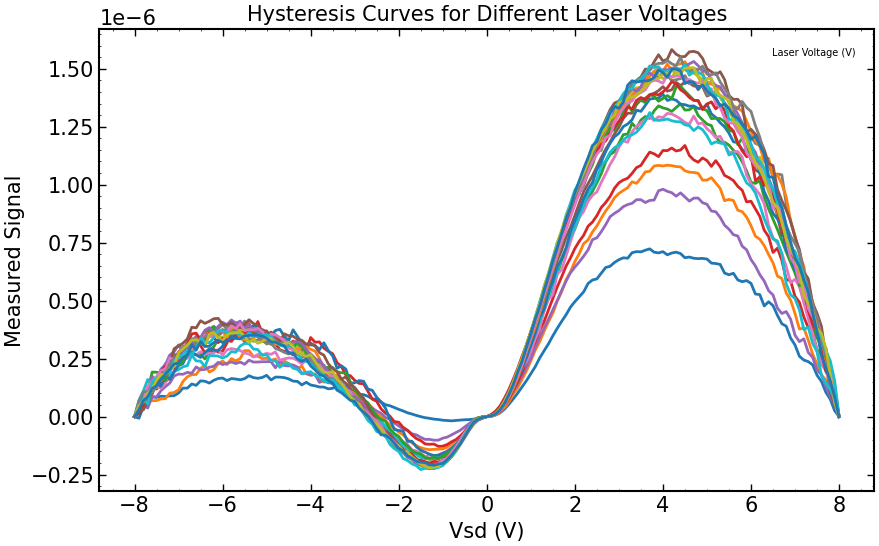

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))  # Create figure and axis

for _, row in hyst_455_v8.iterrows():  
    data_key = row["data_key"]  # Get the key for the dataset
    laser_voltage = row["Laser voltage"]  # Get the laser voltage for labeling
    df = data_hyst[data_key]()  # Load the corresponding dataset
    
    ax.plot(df["Vsd (V)"], df.iloc[:, 1])  # Use second column as y-data

ax.set_xlabel("Vsd (V)")
ax.set_ylabel("Measured Signal")
ax.set_title("Hysteresis Curves for Different Laser Voltages")
ax.legend(title="Laser Voltage (V)")
#ax.grid(True)

plt.show()

In [24]:
hyst_365_v8_1 = (
    c
    .query("`VSD end` == 8 and `Laser wavelength` == 365 and `Information` == 'SnS - 365 - pwr up'")  # Filtering with query
    .loc[lambda df: df["data_key"].str.startswith("365")]  # Applying string filter
    .sort_values("Laser voltage")  # Sorting
)

hyst_365_v8_2 = (
    c
    .query("`VSD end` == 8 and `Laser wavelength` == 365 and `Information` == 'SnS - 365 - pwr down - 1'")  # Filtering with query
    .loc[lambda df: df["data_key"].str.startswith("365")]  # Applying string filter
    .sort_values("Laser voltage")  # Sorting
)


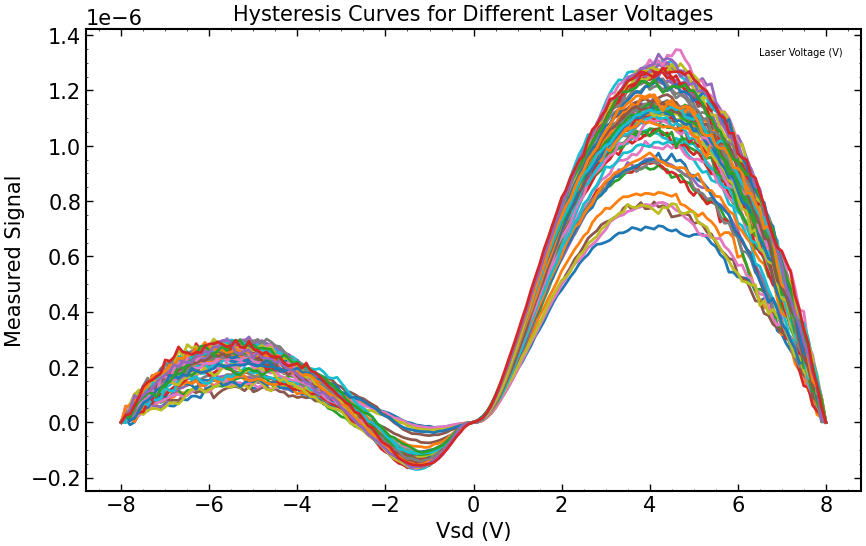

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))  # Create figure and axis

for _, row in hyst_365_v8.iterrows():  
    data_key = row["data_key"]  # Get the key for the dataset
    laser_voltage = row["Laser voltage"]  # Get the laser voltage for labeling
    df = data_hyst[data_key]()  # Load the corresponding dataset
    
    ax.plot(df["Vsd (V)"], df.iloc[:, 1])  # Use second column as y-data

ax.set_xlabel("Vsd (V)")
ax.set_ylabel("Measured Signal")
ax.set_title("Hysteresis Curves for Different Laser Voltages")
ax.legend(title="Laser Voltage (V)")
#ax.grid(True)
plt.savefig("hola.png")
plt.show()

<Axes: xlabel='Laser voltage'>

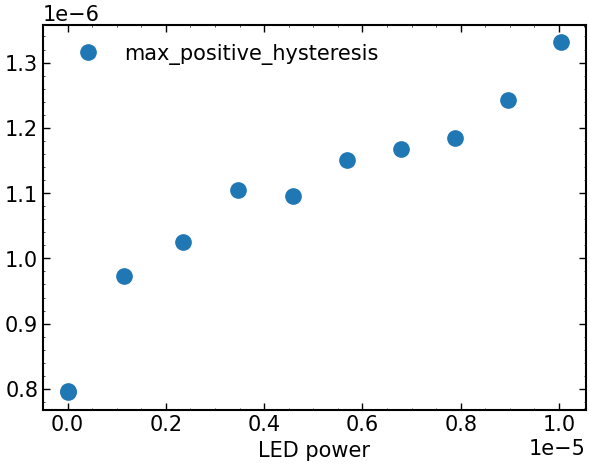

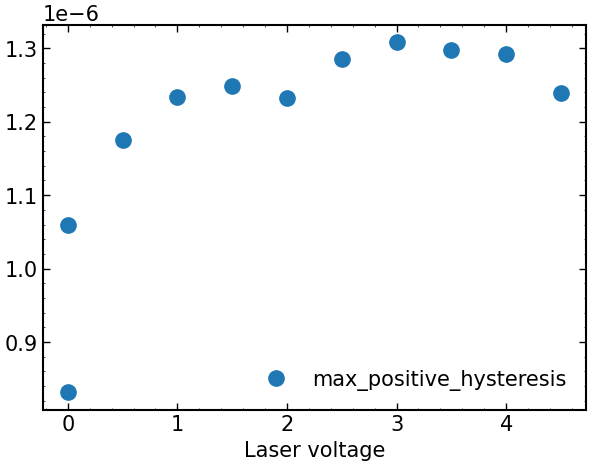

In [26]:

# We know this entire DataFrame uses wavelength=365
wl = 365

# Convert Laser voltage → LED power
hyst_365_v8_1["LED power"] = hyst_365_v8_1["Laser voltage"].apply(calibration_fns[wl])

# Plot
hyst_365_v8_1.plot(x="LED power", y="max_positive_hysteresis", style="o")

hyst_365_v8_2["LED power"] = hyst_365_v8_2["Laser voltage"].apply(calibration_fns[wl])
hyst_365_v8_2.plot(x="Laser voltage", y="max_positive_hysteresis", style="o")

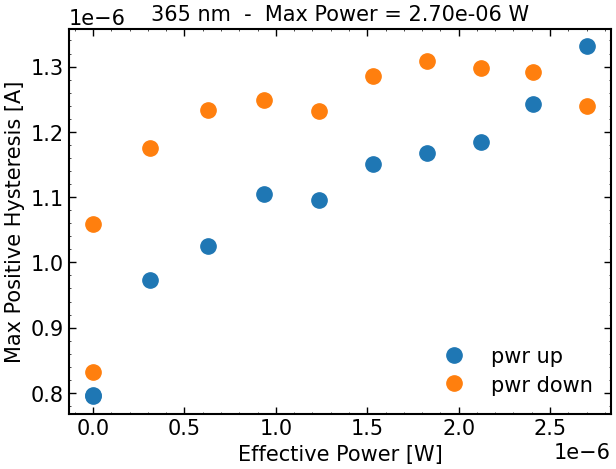

In [27]:

wl = 365

# 1) Convert Laser voltage → LED power in the first DataFrame
hyst_365_v8_1["LED power"] = hyst_365_v8_1["Laser voltage"].apply(calibration_fns[wl]) * factor


# 2) Plot the first dataset, capturing the Axes
ax = hyst_365_v8_1.plot(
    x="LED power", 
    y="max_positive_hysteresis", 
    style="o", 
    label="pwr up"
)

# 3) Convert Laser voltage → LED power in the second DataFrame
hyst_365_v8_2["LED power"] = hyst_365_v8_2["Laser voltage"].apply(calibration_fns[wl]) * factor

# 4) Plot the second dataset on the same Axes
hyst_365_v8_2.plot(
    x="LED power", 
    y="max_positive_hysteresis", 
    style="o", 
    label="pwr down", 
    ax=ax
)
# 3) Find max power row
max_idx = hyst_365_v8_2["LED power"].idxmax()
max_power = hyst_365_v8_2.loc[max_idx, "LED power"]
max_hyst = hyst_365_v8_2.loc[max_idx, "max_positive_hysteresis"]


# (Optional) Customize the figure
plt.title(f"365 nm  -  Max Power = {max_power:.2e} W")
plt.xlabel("Effective Power [W]")
plt.ylabel("Max Positive Hysteresis [A]")
plt.savefig("365.png")
plt.show()


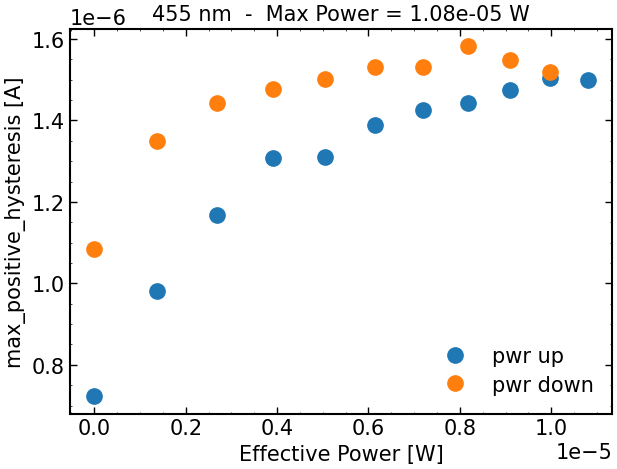

In [31]:
# 1) Select your wavelength & optional factor
wl = 455

# 2) Convert Laser voltage → LED power for first DataFrame
hyst_455_v8_1["LED power"] = hyst_455_v8_1["Laser voltage"].apply(calibration_fns[wl]) * factor

# 3) Plot the first dataset, capturing the Axes object
ax = hyst_455_v8_1.plot(
    x="LED power",
    y="max_positive_hysteresis",
    style="o",       # marker=circles, no line
    label="pwr up"
)

# 4) Convert Laser voltage → LED power for second DataFrame
hyst_455_v8_2["LED power"] = hyst_455_v8_2["Laser voltage"].apply(calibration_fns[wl]) * factor

# 5) Plot the second dataset on the same Axes
hyst_455_v8_2.plot(
    x="LED power",
    y="max_positive_hysteresis",
    style="o",
    ax=ax,
    label="pwr down"
)

# 3) Find max power row
max_idx = hyst_455_v8_1["LED power"].idxmax()
max_power = hyst_455_v8_1.loc[max_idx, "LED power"]
max_hyst = hyst_455_v8_1.loc[max_idx, "max_positive_hysteresis"]


# (Optional) Customize
plt.title(f"455 nm  -  Max Power = {max_power:.2e} W")
plt.xlabel("Effective Power [W]")
plt.ylabel("max_positive_hysteresis [A]")
plt.legend()
plt.savefig("455.png")
plt.show()

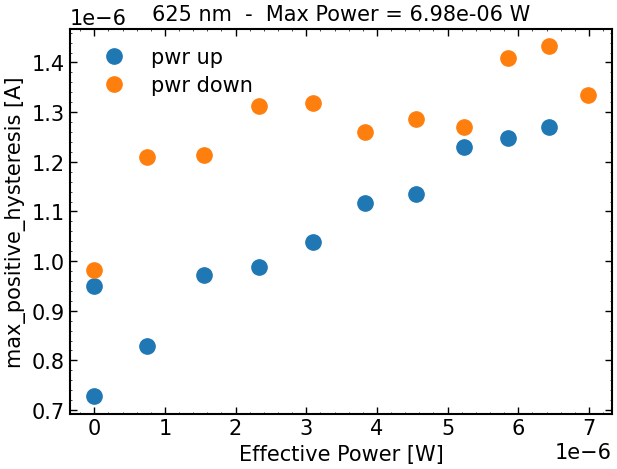

In [29]:

# 1) Set your wavelength & optional factor
wl = 625

# 2) Convert Laser voltage → LED power for the first DataFrame
hyst_625_v8_1["LED power"] = hyst_625_v8_1["Laser voltage"].apply(calibration_fns[wl]) * factor

# 3) Plot the first dataset, capturing the Axes object
ax = hyst_625_v8_1.plot(
    x="LED power", 
    y="max_positive_hysteresis", 
    style="o",    # marker=circles
    label="pwr up"
)

# 4) Convert Laser voltage → LED power for the second DataFrame
hyst_625_v8_2["LED power"] = hyst_625_v8_2["Laser voltage"].apply(calibration_fns[wl]) * factor

# 5) Plot the second dataset on the same Axes
hyst_625_v8_2.plot(
    x="LED power",
    y="max_positive_hysteresis",
    style="o",
    ax=ax,
    label="pwr down"
)

# 3) Find max power row
max_idx = hyst_625_v8_2["LED power"].idxmax()
max_power = hyst_625_v8_2.loc[max_idx, "LED power"]
max_hyst = hyst_625_v8_2.loc[max_idx, "max_positive_hysteresis"]


# (Optional) Customize
plt.title(f"625 nm  -  Max Power = {max_power:.2e} W")
plt.xlabel("Effective Power [W]")
plt.ylabel("max_positive_hysteresis [A]")
plt.savefig("625.png")
plt.legend()
plt.show()

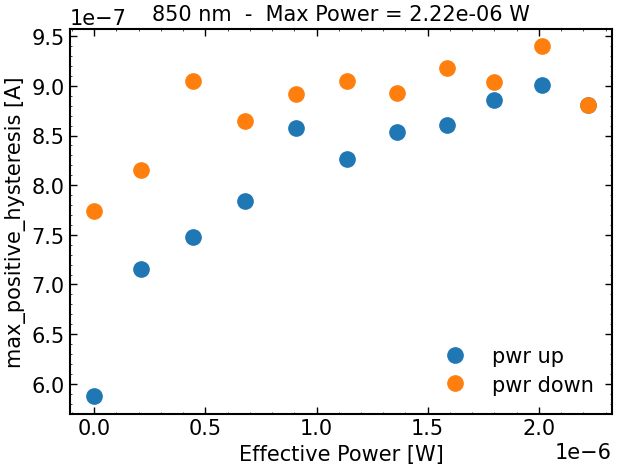

In [30]:

wl = 850


# 1) Convert Laser voltage → LED power for the first DataFrame
hyst_850_v8_1["LED power"] = hyst_850_v8_1["Laser voltage"].apply(calibration_fns[wl]) * factor

# 2) Plot the first dataset, capturing the Axes object
ax = hyst_850_v8_1.plot(
    x="LED power",
    y="max_positive_hysteresis",
    style="o",     # marker=circles, no line
    label="pwr up"
)

# 3) Convert Laser voltage → LED power for the second DataFrame
hyst_850_v8_2["LED power"] = hyst_850_v8_2["Laser voltage"].apply(calibration_fns[wl]) * factor

# 4) Plot the second dataset on the same Axes
hyst_850_v8_2.plot(
    x="LED power",
    y="max_positive_hysteresis",
    style="o",
    ax=ax,
    label="pwr down"
)

# 3) Find max power row
max_idx = hyst_850_v8_2["LED power"].idxmax()
max_power = hyst_850_v8_2.loc[max_idx, "LED power"]
max_hyst = hyst_850_v8_2.loc[max_idx, "max_positive_hysteresis"]



# (Optional) Customize
plt.title(f"850 nm  -  Max Power = {max_power:.2e} W")
plt.xlabel("Effective Power [W]")
plt.ylabel("max_positive_hysteresis [A]")
plt.legend()
plt.savefig("850.png")
plt.show()
